In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
#from core.data import load_from_kaggle

# Styling für bessere Visualisierungen
#plt.rcParams['figure.figsize'] = (12, 6)
#plt.rcParams['figure.dpi'] = 100

In [4]:
# Lädt die Datei direkt aus dem Unterordner
df = pd.read_csv("data/data_in_use/diabetes_binary_health_indicators_BRFSS2015.csv")

# Erste 5 Zeilen anzeigen
df.head(5)

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
#Check Dopplung
df.duplicated().sum()

np.int64(24206)

In [6]:
 # Zeigt alle Zeilen an, die im Datensatz mehrfach vorkommen
df_duplicates = df[df.duplicated(keep=False)]
df_duplicates

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
5,0.0,1.0,1.0,1.0,25.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,2.0,0.0,1.0,10.0,6.0,8.0
25,0.0,0.0,0.0,1.0,32.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0
29,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
44,0.0,0.0,1.0,1.0,31.0,1.0,0.0,0.0,0.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0
52,1.0,1.0,1.0,1.0,27.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,0.0,30.0,1.0,0.0,10.0,4.0,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253492,1.0,1.0,1.0,1.0,33.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,9.0,6.0,6.0
253550,0.0,0.0,0.0,1.0,25.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,7.0,6.0,8.0
253563,0.0,0.0,1.0,1.0,24.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,1.0,8.0,6.0,8.0
253597,0.0,0.0,0.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,5.0,6.0,8.0


In [7]:
# Gruppiert alle identischen Zeilen und zählt, wie oft jedes Profil vorkommt
haeufigste_profile = df.value_counts()

# Zeigt die Top 5 der am häufigsten vorkommenden Profile
haeufigste_profile


Diabetes_binary  HighBP  HighChol  CholCheck  BMI   Smoker  Stroke  HeartDiseaseorAttack  PhysActivity  Fruits  Veggies  HvyAlcoholConsump  AnyHealthcare  NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex  Age   Education  Income
0.0              0.0     0.0       1.0        21.0  0.0     0.0     0.0                   1.0           1.0     1.0      0.0                1.0            0.0          1.0      0.0       0.0       0.0       0.0  6.0   6.0        8.0       59
                                              23.0  0.0     0.0     0.0                   1.0           1.0     1.0      0.0                1.0            0.0          1.0      0.0       0.0       0.0       0.0  6.0   6.0        8.0       55
                                                                                                                                                                                                                    7.0   6.0        8.0       53
                                      

In [8]:
# Das absolut häufigste Profil ermitteln (Index 0 der sortierten Liste)
haeufigstes_profil_index = df.value_counts().index[0]
haeufigstes_profil_anzahl = df.value_counts().iloc[0]

# Als schöne Tabelle für PowerPoint darstellen
df_top_profil = pd.DataFrame([haeufigstes_profil_index], columns=df.columns)

print(f"Dieses Profil kommt exakt {haeufigstes_profil_anzahl} Mal im Datensatz vor:\n")
df_top_profil.T  # .T dreht die Tabelle hochkant, damit man alle 21 Spalten leicht untereinander lesen kann


Dieses Profil kommt exakt 59 Mal im Datensatz vor:



,0
Diabetes_binary,0.0
HighBP,0.0
HighChol,0.0
CholCheck,1.0
BMI,21.0
Smoker,0.0
Stroke,0.0
HeartDiseaseorAttack,0.0
PhysActivity,1.0
Fruits,1.0


In [9]:
# Zeigt Spaltennamen, Anzahl Werte und Datentyp an
df.info()

# 8-Werte-Übersicht pro Spalte
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [10]:
# Check missing values

df_NaN_True = df.isna()   #mit den beiden Zeilen Anzahl den NaN
df_NaN_True.sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [11]:
# Daten strukturell in (X) und (y) aufgeteilt, 
# wie man es für eine logistische Regression vorbereiten würde. 
# Der Datensatz bleibt so organisiert, daß im Folgenden 
# statistischen Häufigkeiten zwischen den Gruppen analysiert 
# werden kann

# Datenanalyse und Visualisierung 

# 1) nach Geschlecht

# 2) nach BMI

In [12]:
# 1) nach Geschlecht

In [13]:
print(len(df['Sex']))
print(df['Sex'].map({0.0: 'Frauen (0.0)', 1.0: 'Männer (1.0)'}).value_counts())

253680
Sex
Frauen (0.0)    141974
Männer (1.0)    111706
Name: count, dtype: int64


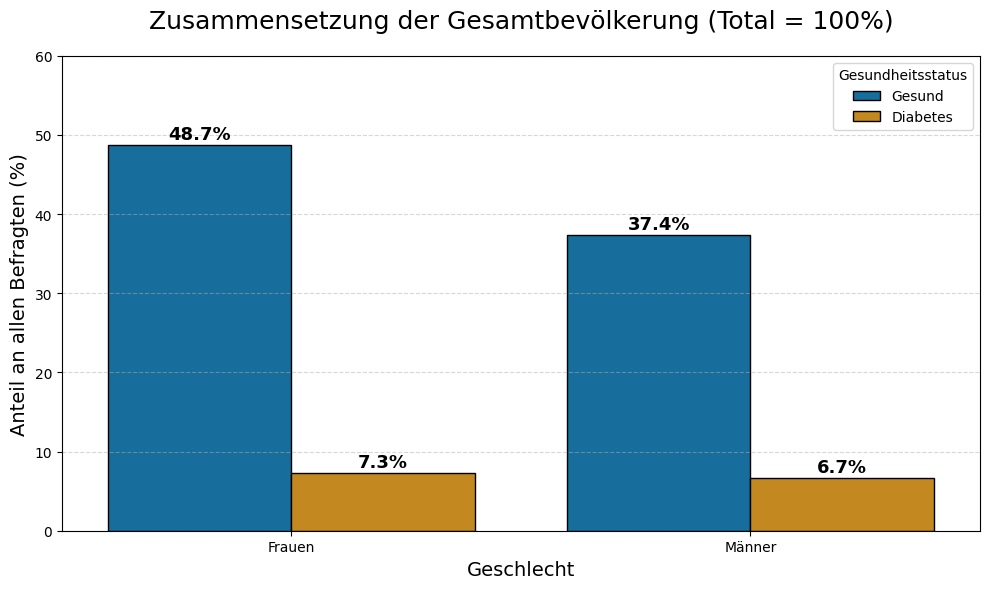

In [14]:
# Zusammensetzung gesamt und nach Geschlecht
import pandas as pd  # <-- Das löst den NameError für 'pd'
import matplotlib.pyplot as plt
import seaborn as sns



# Berechne den prozentualen Anteil jeder Kombination an der GESAMTANZAHL (Total = 100%)
gesamt_aufteilung = pd.crosstab(df['Sex'], df['Diabetes_binary'], normalize='all') * 100

# Umwandeln in ein für Seaborn leicht lesbares Format
gesamt_df = gesamt_aufteilung.stack().reset_index()
gesamt_df.columns = ['Geschlecht', 'Diabetes_Status', 'Prozent_an_Gesamtpopulation']

# Beschriftungen für die Folie verständlich übersetzen
gesamt_df['Geschlecht'] = gesamt_df['Geschlecht'].map({0.0: 'Frauen', 1.0: 'Männer'})
gesamt_df['Diabetes_Status'] = gesamt_df['Diabetes_Status'].map({0.0: 'Gesund', 1.0: 'Diabetes'})

# Plot erstellen mit Seaborn
plt.figure(figsize=(10, 6))

# HIER NUTZEN WIR DAS FARBBLINDEN-SCHEMA:
# Die Palette 'colorblind' liefert standardmäßig Blau für die erste und Orange für die zweite Gruppe.
ax = sns.barplot(
    data=gesamt_df, 
    x='Geschlecht', 
    y='Prozent_an_Gesamtpopulation', 
    hue='Diabetes_Status', 
    palette='colorblind',  # Aktiviert das barrierefreie Farbschema
    edgecolor='black'
)

# Styling für eine saubere, gut lesbare PowerPoint-Folie
plt.title('Zusammensetzung der Gesamtbevölkerung (Total = 100%)', fontsize=18, pad=20)
plt.xlabel('Geschlecht', fontsize=14)
plt.ylabel('Anteil an allen Befragten (%)', fontsize=14)
plt.ylim(0, 60)  # Genug Platz nach oben für die Text-Labels
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Legende anpassen
plt.legend(title="Gesundheitsstatus", loc='upper right')

# Prozentzahlen exakt über die Balken schreiben
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f"{height:.1f}%", 
                    (p.get_x() + p.get_width() / 2., height + 0.8),
                    ha='center', va='baseline', color='black', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()


In [15]:
# 2) nach BMI

In [77]:

print(df[["BMI", "BMI_Kategorie_Text"]].value_counts().sort_index())

df[df["BMI"] >= 40]["BMI"].value_counts()

BMI   BMI_Kategorie_Text        
12.0  Underweight (<18.5)             6
13.0  Underweight (<18.5)            21
14.0  Underweight (<18.5)            41
15.0  Underweight (<18.5)           132
16.0  Underweight (<18.5)           348
                                   ... 
91.0  Obesity Class III (>=40.0)      1
92.0  Obesity Class III (>=40.0)     32
95.0  Obesity Class III (>=40.0)     12
96.0  Obesity Class III (>=40.0)      1
98.0  Obesity Class III (>=40.0)      7
Name: count, Length: 84, dtype: int64


BMI
40.0    2258
41.0    1659
42.0    1639
43.0    1500
44.0    1043
45.0     819
46.0     750
47.0     622
48.0     484
49.0     416
50.0     372
51.0     253
53.0     237
52.0     215
55.0     169
54.0     113
56.0     109
57.0      86
58.0      71
79.0      66
60.0      63
87.0      61
77.0      55
59.0      54
75.0      52
81.0      49
71.0      49
73.0      47
84.0      44
62.0      43
82.0      37
61.0      35
63.0      34
92.0      32
89.0      28
64.0      24
65.0      19
74.0      16
67.0      15
70.0      15
68.0      14
72.0      14
66.0      13
95.0      12
69.0       9
98.0       7
76.0       3
88.0       2
83.0       2
80.0       2
85.0       1
96.0       1
91.0       1
86.0       1
90.0       1
78.0       1
Name: count, dtype: int64

In [78]:
# 1. Spalten erstellen und nach aktueller WHO-Klassifikation einordnen

def bmi_kategorie_who(bmi):
    if bmi < 18.5:
        return 'Underweight (<18.5)'
    elif bmi < 25.0:
        return 'Normal weight (18.5-24.9)'
    elif bmi < 30.0:
        return 'Overweight (25.0-29.9)'
    elif bmi < 35.0:
        return 'Obesity Class I (30.0-34.9)'
    elif bmi < 40.0:
        return 'Obesity Class II (35.0-39.9)'
    else:
        return 'Obesity Class III (>=40.0)'

# Neue Spalte mit den Kategorien anlegen
df['BMI_Kategorie_Text'] = df['BMI'].apply(bmi_kategorie_who)

# Die Reihenfolge für die Ausgabe definieren
reihenfolge_who = [
    'Underweight (<18.5)', 
    'Normal weight (18.5-24.9)', 
    'Overweight (25.0-29.9)', 
    'Obesity Class I (30.0-34.9)', 
    'Obesity Class II (35.0-39.9)', 
    'Obesity Class III (>=40.0)'
]

# 2. Absolute Häufigkeiten berechnen
bmi_counts = df['BMI_Kategorie_Text'].value_counts().reindex(reihenfolge_who)

print("--- 1. Absolute Anzahl Personen im Datensatz ---")
print() # Abstandszeile
for kat in reihenfolge_who:
    anzahl = bmi_counts[kat]
    print(f"{kat:<28} | Anzahl Personen: {anzahl:,}")
print() # Abstandszeile   

# 3. Reale Diabetes-Rate (in %) innerhalb der Gruppen berechnen
bmi_rates_who = df.groupby('BMI_Kategorie_Text')['Diabetes_binary'].mean() * 100

print("--- 2. Reale Diabetes-Rate innerhalb der Gruppen ---")
print() # Abstandszeile
for kat in reihenfolge_who:
    rate = bmi_rates_who[kat]
    print(f"{kat:<28} | Diabetes-Rate: {rate:.1f}%")
    


--- 1. Absolute Anzahl Personen im Datensatz ---

Underweight (<18.5)          | Anzahl Personen: 3,127
Normal weight (18.5-24.9)    | Anzahl Personen: 68,953
Overweight (25.0-29.9)       | Anzahl Personen: 93,749
Obesity Class I (30.0-34.9)  | Anzahl Personen: 53,451
Obesity Class II (35.0-39.9) | Anzahl Personen: 20,663
Obesity Class III (>=40.0)   | Anzahl Personen: 13,737

--- 2. Reale Diabetes-Rate innerhalb der Gruppen ---

Underweight (<18.5)          | Diabetes-Rate: 5.4%
Normal weight (18.5-24.9)    | Diabetes-Rate: 5.7%
Overweight (25.0-29.9)       | Diabetes-Rate: 11.4%
Obesity Class I (30.0-34.9)  | Diabetes-Rate: 19.2%
Obesity Class II (35.0-39.9) | Diabetes-Rate: 27.4%
Obesity Class III (>=40.0)   | Diabetes-Rate: 33.5%


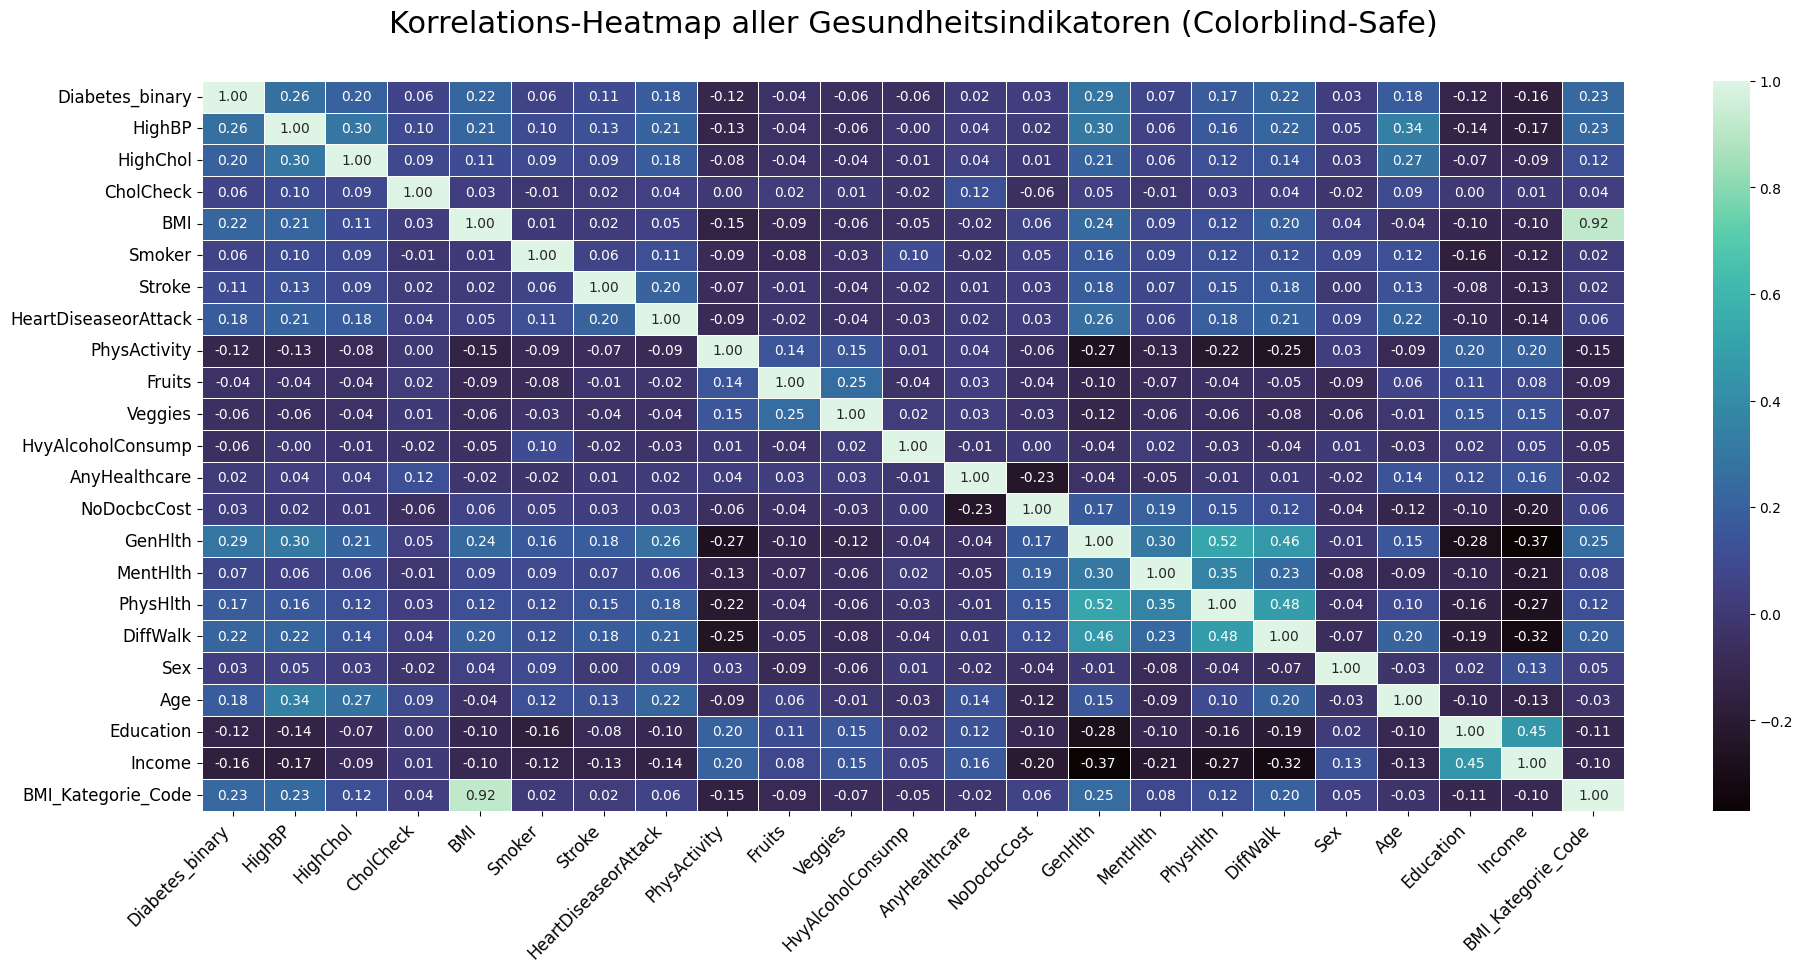

In [81]:
# Korrelations - Heatmap

# 1. Nur die numerischen Spalten auswählen (schließt die Text-Kategorien aus)
df_numerisch = df.select_dtypes(include=['number'])

# 2. Die Korrelationsmatrix berechnen
corr_matrix = df_numerisch.corr()

# 3. Plot erstellen (deine gewählte Größe von 20x10 ist super für die Detailtiefe)
plt.figure(figsize=(20, 10))

# 'mako' ist die moderne, farbblindensichere Wahl für sequentielle Matrizen
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='mako',        # Barrierefreie Palette für Heatmaps
    fmt=".2f",          # Rundet alle Korrelationswerte sauber auf 2 Nachkommastellen
    linewidths=0.5,     # Zieht feine Trennlinien zwischen die Quadrate
    annot_kws={"size": 10} # Schriftgröße der Zahlen in den Kästchen optimal anpassen
)

# 4. Styling für deine PowerPoint-Folie (Erweiterte Ränder)
plt.title('Korrelations-Heatmap aller Gesundheitsindikatoren (Colorblind-Safe)', fontsize=22, pad=35)

# Beschriftungen drehen, damit die langen Spaltennamen nicht ineinander laufen
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(rotation=0, fontsize=12)

# Ränder großzügig absichern, damit beim Export absolut nichts abgeschnitten wird
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.15) 

# Optionale Speicherung in hoher Qualität für PowerPoint
# plt.savefig('heatmap_colorblind.png', dpi=300, bbox_inches='tight')

plt.show()




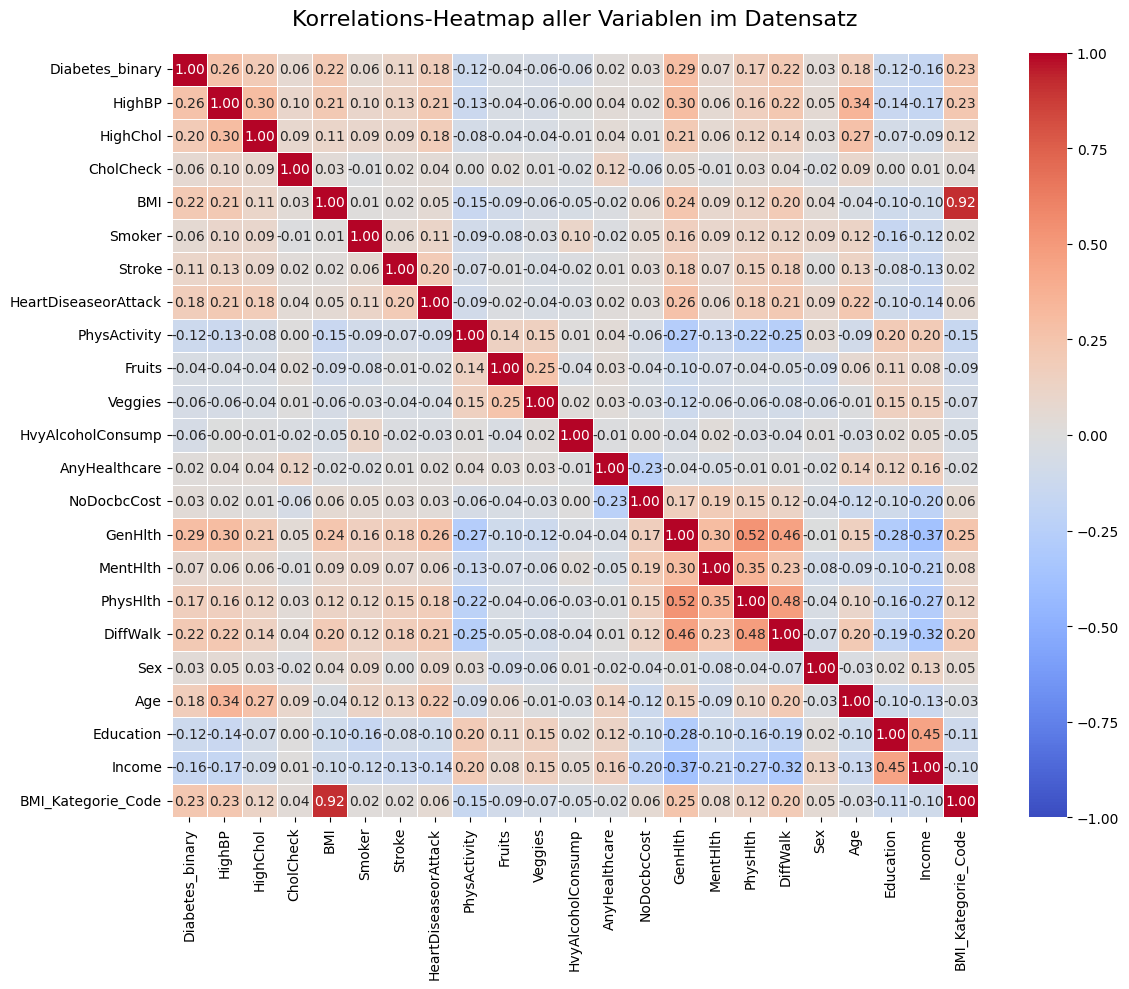

In [84]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Korrelationsmatrix für den gesamten DataFrame berechnen
corr_matrix = df_numerisch.corr()

# 2. Diagrammgröße anpassen 
plt.figure(figsize=(12, 10))

# 3. Heatmap plotten
sns.heatmap(
    corr_matrix,
    annot=True,            # Schreibt die Korrelationswerte in die Boxen
    fmt=".2f",             # 2 Nachkommastellen
    cmap="coolwarm",   
    vmin=-1,
    vmax=1,                # Skala festlegen
    linewidths=0.5,
    annot_kws={"fontsize": 10},
)

plt.title(
    "Korrelations-Heatmap aller Variablen im Datensatz", fontsize=16, pad=20
)
plt.tight_layout()
plt.show()
